100%|██████████| 170M/170M [02:31<00:00, 1.12MB/s] 


Extracting ./cifar-10-python.tar.gz to ./
Files already downloaded and verified


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

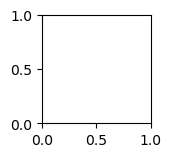

In [ ]:
# 데이터 전처리, 데이터 증강
import matplotlib.pyplot as plt
from torchvision.datasets.cifar import CIFAR10
from torchvision.transforms import ToTensor

# 데이터셋 불러오기
training_dataset = CIFAR10 (
    root = './',
    train = True,
    download=True,
    transform=ToTensor()
)


test_dataset = CIFAR10 (
    root = './',
    train = False,
    download=True,
    transform=ToTensor()
)



In [3]:
training_dataset[0]
# tuple : 
# 이미지데이터, 이미지라벨형태

(tensor([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
          [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
          [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
          ...,
          [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
          [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
          [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],
 
         [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
          [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
          [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
          ...,
          [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
          [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
          [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],
 
         [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
          [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
          [0.0824, 0.0000, 0.0314,  ...,

In [ ]:
#matplot 은 채널 정보가 뒤에 와야함..  변경
training_dataset[0][0].size()
training_dataset[0][0].view(32,32,3).size()
# view(32,32,3)은 자리가 재배치 된것?????? 그래서 하면 안됨???

torch.Size([32, 32, 3])

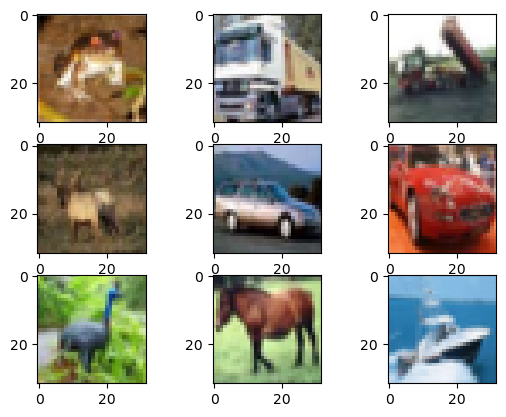

In [8]:
for i in range(9):
    img, label = training_dataset[i]
    plt.subplot(3,3,i+1)
    # plt.imshow(training_dataset[i][0].view(32,32,3)) # 하면 안됨??
    plt.imshow (img.permute(1,2,0))  #(C,H,W): 0 1 2 -- 1 2 0 (H,W,C) 데이터 위치만 변경
plt.show()




100%|██████████| 170M/170M [02:35<00:00, 1.10MB/s] 


Extracting ./cifar-10-python.tar.gz to ./
Files already downloaded and verified


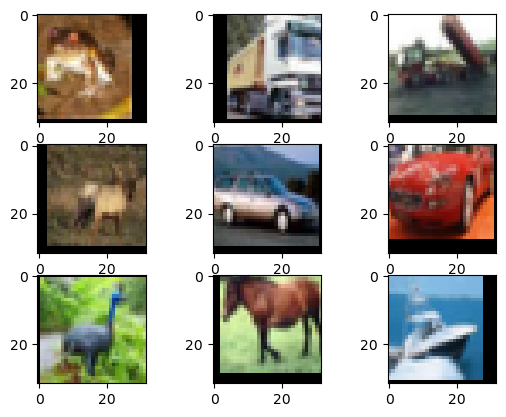

In [ ]:
# 크롭핑과 뒤집기 추가 
    # 크롭 : 테두리 자르기
    # horizontal :  좌우 반전
# 이미지는 노이즈가 있으면 학습이 더 잘됨?


import torchvision.transforms as T 
from torchvision.transforms import Compose
from torchvision.transforms import RandomHorizontalFlip, RandomCrop

transform = Compose([
    T.ToTensor(),
    RandomCrop( (32,32), padding=4),
    RandomHorizontalFlip(p=0.5),
])

training_dataset = CIFAR10 (
    root = './',
    train = True,
    download=True,
    transform=transform
)


test_dataset = CIFAR10 (
    root = './',
    train = False,
    download=True,
    transform=transform
)

for i in range(9):
    img, label = training_dataset[i]
    plt.subplot(3,3,i+1)
    plt.imshow (img.permute(1,2,0))  #(C,H,W): 0 1 2 -- 1 2 0 (H,W,C) 데이터 위치만 변경
plt.show()

Files already downloaded and verified
Files already downloaded and verified


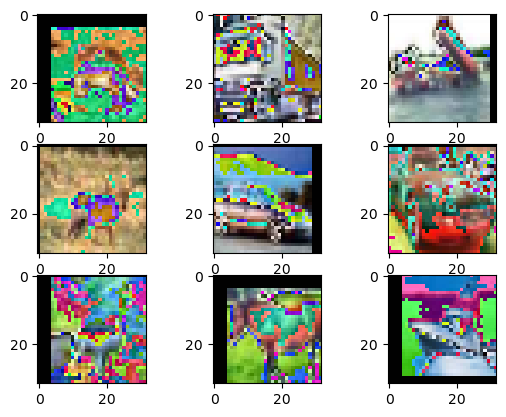

In [14]:
# 데이터 전처리에 정규화 추가
from torchvision.transforms import RandomHorizontalFlip, RandomCrop, Normalize

transform = Compose([
    T.ToPILImage(),
    RandomCrop( (32,32), padding=4),
    RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    # 데이터 정규화 Noarmalize (평균, 표준편차)
    Normalize( (0.5, 0.5, 0.5), (0.5,0.5,0.5)),
    T.ToPILImage()
])


training_dataset = CIFAR10 (
    root = './',
    train = True,
    download=True,
    transform=transform
)


test_dataset = CIFAR10 (
    root = './',
    train = False,
    download=True,
    transform=transform
)

for i in range(9):
    # img, label = training_dataset[i]
    plt.subplot(3,3,i+1)
    # plt.imshow (img.permute(1,2,0))  #(C,H,W): 0 1 2 -- 1 2 0 (H,W,C) 데이터 위치만 변경
    plt.imshow(transform(training_dataset.data[i]))
plt.show()

### VGG
https://wikidocs.net/164796
- VGG16 Architecture
- VGG 이름의 숫자 16은 16계층 심층신경망(VGGnet)이라는 사실을 나타냅니다
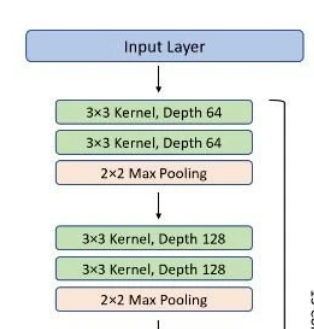

In [ ]:
#######실행1

import torch.nn as nn
class BasicBlock(nn.Module):
    def __init__ (self, int_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(int_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
    def forward(self, x) : 
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        out = self.pool(x)
        return out

In [ ]:
#######실행2

import torch
class CNN(nn.Module):
    def __init__ (self, num_class):
        super(CNN, self).__init__()
        
        #상기 셀에 BasicBlock에 정의된 순서 int_channels, out_channels, hidden_dim  
        self.block1 = BasicBlock(3, 64, 64)   # c c p :  (3,32,32) --> (64, 32, 32) --> (64, 32,32) --> (64, 16, 16)
        self.block2 = BasicBlock(64, 128, 128) # --> (128, 16, 16) --> (128, 16, 16) --> (128, 8, 8)

        # 분류기
        self.fc1 = nn.Linear ( 128*8*8,2048)     
        self.fc2 = nn.Linear (2048, 256)
        self.fc3 = nn.Linear (256, num_class)
        self.relu = nn.ReLU()

    def forward (self, x):
        x= self.block1(x)
        x= self.block2(x)
        # (-1,128*8*)
        x=torch.flatten(x,start_dim=1) # 1d로 펴주기. 데이터갯수는 두고..???
        x= self.relu (self.fc1(x)) #왜 relu를 또하지??????????????????????????
        x= self.relu (self.fc2(x))
        out= self.fc3(x)
        return out 


In [ ]:
# 샘플데이터 생성해서 구조 확인하기 : for 문 등에서 수정하기 어려우므로 중간단계에서 확인할 것
X = torch.randn (4,3,32,32)
model = CNN(10)
model(X)

tensor([[ 0.0228,  0.0483, -0.0364, -0.0031,  0.0350, -0.0621, -0.0801,  0.0368,
          0.0744, -0.0146],
        [ 0.0209,  0.0482, -0.0317, -0.0033,  0.0389, -0.0642, -0.0796,  0.0361,
          0.0706, -0.0138],
        [ 0.0203,  0.0471, -0.0347, -0.0018,  0.0368, -0.0620, -0.0822,  0.0375,
          0.0720, -0.0125],
        [ 0.0218,  0.0479, -0.0364, -0.0064,  0.0365, -0.0627, -0.0797,  0.0387,
          0.0748, -0.0148]], grad_fn=<AddmmBackward0>)

In [34]:
#######실행3

# 데이터 증강
transform = Compose([
    RandomCrop( (32,32), padding=4),
    RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    # 데이터 정규화 Noarmalize (평균, 표준편차)
    Normalize( (0.5, 0.5, 0.5), (0.5,0.5,0.5))
])


# 데이터 셋
training_dataset = CIFAR10 (root = './', train = True, download=True, transform=transform)
test_dataset = CIFAR10 (root = './', train = False, download=True,transform=transform)
    # 테스트는 상기 데이터 증강 없이 ToTensor()만 하면 됨.


# 데이터 로더
from torch.utils.data.dataloader import DataLoader
train_loader = DataLoader(training_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNN(10)
model.to(device)



Files already downloaded and verified
Files already downloaded and verified


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=8192, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
)

In [ ]:
# model.fc3 를 통해서 레이어에 접근 및 변경이 가능함.
# model.fc3 = nn.Linear(in_features=256, out_features=2, bias=True)

In [29]:
%pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# 모델 layer에 통과한 후 output shape 확인
from torchsummary import summary
model = CNN(10)
summary(model, (3,32,32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
            Conv2d-3           [-1, 64, 32, 32]          36,928
              ReLU-4           [-1, 64, 32, 32]               0
         MaxPool2d-5           [-1, 64, 16, 16]               0
        BasicBlock-6           [-1, 64, 16, 16]               0
            Conv2d-7          [-1, 128, 16, 16]          73,856
              ReLU-8          [-1, 128, 16, 16]               0
            Conv2d-9          [-1, 128, 16, 16]         147,584
             ReLU-10          [-1, 128, 16, 16]               0
        MaxPool2d-11            [-1, 128, 8, 8]               0
       BasicBlock-12            [-1, 128, 8, 8]               0
           Linear-13                 [-1, 2048]      16,779,264
             ReLU-14                 [-

In [ ]:
# 학습에 참여하는 가중치 정보
for name, param in model.named_parameters():
    print(f'{name} {list(param.shape)}')

block1.conv1.weight [64, 3, 3, 3]
block1.conv1.bias [64]
block1.conv2.weight [64, 64, 3, 3]
block1.conv2.bias [64]
block2.conv1.weight [128, 64, 3, 3]
block2.conv1.bias [128]
block2.conv2.weight [128, 128, 3, 3]
block2.conv2.bias [128]
fc1.weight [2048, 8192]
fc1.bias [2048]
fc2.weight [256, 2048]
fc2.bias [256]
fc3.weight [10, 256]
fc3.bias [10]


In [35]:
#######실행4

# 하이퍼 파라미터
from torch.optim import Adam 
lr = 1e-3
optimizer = Adam(model.parameters(), lr=lr)
epochs = 5


from tqdm import tqdm 
# 학습루프
for epoch in range(epochs):
    for data, label in tqdm(train_loader):
        optimizer.zero_grad()
        preds = model (data.to(device))
        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optimizer.step()
        
    if (epoch+1)%10==0:
        print(f'epoch {epoch+1}, loss {loss.item()}')

torch.save(model.state_dict(), 'cifar.pth')  #torch에는 모델 저장 기능이 있음 / 가중치만 저장되어있음./ 모델구조는 저장되어 있지 않음. (모델+가중치 저장되는 것도 있음. 용량 많이 차지함)
        


100%|██████████| 196/196 [04:24<00:00,  1.35s/it]


In [36]:
#######실행5
# 평가
model.load_state_dict(torch.load('cifar.pth', map_location=device, weights_only=True))


# 예측
num_corr=0
with torch.no_grad():
    for data, label in test_loader :
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr =+ corr
    print(f'Accuracy : {num_corr/len(test_loader)}')

Accuracy : 0.25


In [ ]:
from torchvision import models
vgg16_model = models.vgg16()
